# Notebook 1: Base Models para Séries Temporais

Este notebook implementa todos os **Base Models** estudados na Aula 2.

## Modelos implementados:
1. Média Histórica (Global)
2. Média Acumulada
3. Média Móvel Simples (SMA)
4. Média Móvel Exponencial (EMA)
5. Taxa de Variação
6. Seasonal Naive
7. Delta (Drift)

Cada modelo pode ser aplicado em qualquer base (CSV, Excel, etc.)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 6)

## Métricas de Erro

Implementação das principais métricas de avaliação:
- **MAE** (Mean Absolute Error): média da diferença absoluta
- **MSE** (Mean Squared Error): média dos erros ao quadrado (penaliza erros grandes)
- **RMSE** (Root Mean Squared Error): raiz do MSE, mesma escala dos dados
- **MAPE** (Mean Absolute Percentage Error): erro médio em porcentagem

In [2]:
def calcular_metricas(y_true, y_pred):
    """
    Calcula todas as métricas de erro para avaliação dos modelos.
    
    Parâmetros:
    -----------
    y_true : array-like
        Valores reais
    y_pred : array-like
        Valores previstos
    
    Retorna:
    --------
    dict : Dicionário com MAE, MSE, RMSE e MAPE
    """
    # Remove valores NaN antes de calcular métricas
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = np.array(y_true)[mask]
    y_pred_clean = np.array(y_pred)[mask]
    
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    mse = mean_squared_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true_clean, y_pred_clean) * 100
    
    return {
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAPE': round(mape, 4)
    }

def exibir_resultados(nome_modelo, y_true, y_pred):
    """
    Exibe as métricas de um modelo de forma formatada.
    """
    metricas = calcular_metricas(y_true, y_pred)
    print(f"\n{'='*60}")
    print(f"  {nome_modelo}")
    print(f"{'='*60}")
    for metrica, valor in metricas.items():
        print(f"  {metrica:8s}: {valor:>10}")
    print(f"{'='*60}\n")
    return metricas

## Carregamento de Dados

Carregue sua série temporal aqui. O código aceita:
- Arquivos CSV
- Arquivos Excel (.xlsx, .xls)
- DataFrames do Pandas

**Importante**: A série deve ter pelo menos uma coluna com valores numéricos.

In [3]:
# ===== CONFIGURAÇÃO: AJUSTE AQUI PARA SUA BASE =====

# Opção 1: Carregar de CSV
df = pd.read_csv('dataset1.csv')

# Opção 2: Carregar de Excel
# df = pd.read_excel('sua_serie.xlsx')

# Opção 3: Exemplo com dados de demonstração
df = pd.DataFrame({
    'data': pd.date_range('2020-01-01', periods=100, freq='D'),
    'valor': [10, 12, 14, 13, 15, 17, 16, 18, 20, 19] * 10
})

# DEFINA O NOME DA COLUNA COM OS VALORES DA SÉRIE
coluna_valor = 'valor'

# Visualização dos primeiros dados
print(f"Shape dos dados: {df.shape}")
print(f"\nPrimeiras linhas:")
display(df.head(10))

# Extrair a série para análise
serie = df[coluna_valor].values

Shape dos dados: (100, 2)

Primeiras linhas:


,data,valor
0,2020-01-01,10
1,2020-01-02,12
2,2020-01-03,14
3,2020-01-04,13
4,2020-01-05,15
5,2020-01-06,17
6,2020-01-07,16
7,2020-01-08,18
8,2020-01-09,20
9,2020-01-10,19


## 1. Média Histórica (Global)

**Descrição**: Prevê o próximo valor usando a média global de todos os dados históricos.

**Fórmula**: $\hat{y}_{t+1} = \frac{1}{n} \sum_{i=1}^{n} y_i$

**Quando usar**: Baseline simples, séries muito estáveis sem tendência ou sazonalidade.


  Média Histórica
  MAE     :     2.5717
  MSE     :     9.0388
  RMSE    :     3.0065
  MAPE    :    17.9409



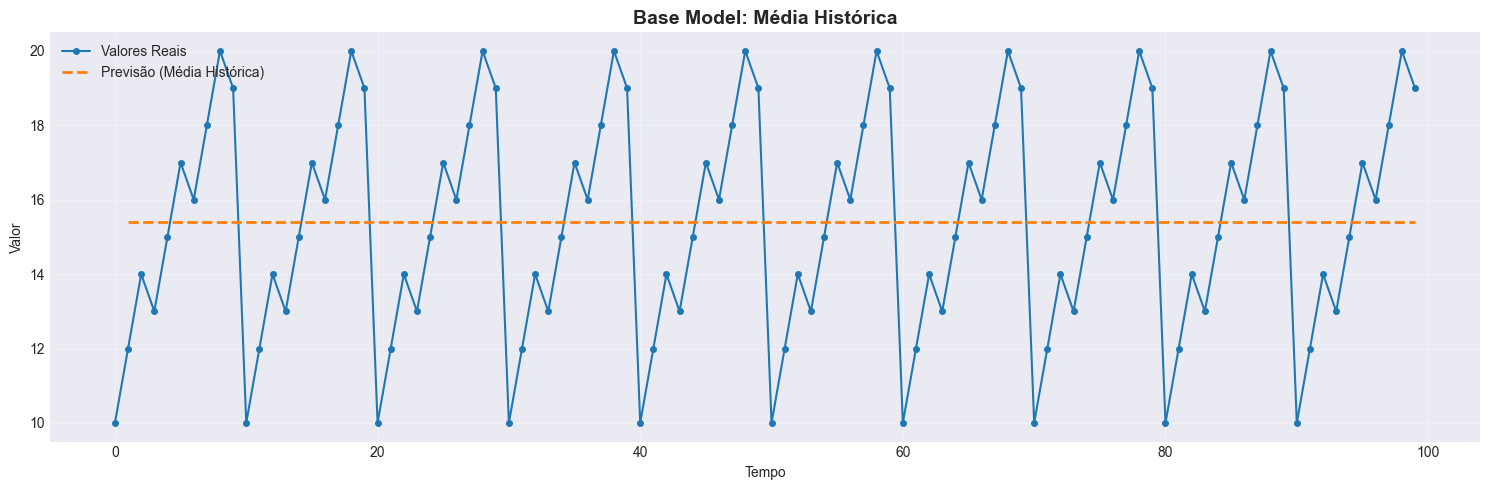

In [4]:
def media_historica(serie):
    """
    Base Model: Média Histórica (Global)
    Prevê todos os valores futuros como a média global da série.
    """
    media_global = np.mean(serie)
    previsoes = np.full(len(serie), media_global)
    previsoes[0] = np.nan  # Primeiro valor não tem previsão
    return previsoes

# Aplicar o modelo
prev_media_hist = media_historica(serie)

# Calcular e exibir métricas
metricas_media_hist = exibir_resultados('Média Histórica', serie, prev_media_hist)

# Visualização
plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4)
plt.plot(prev_media_hist, label='Previsão (Média Histórica)', linestyle='--', linewidth=2)
plt.title('Base Model: Média Histórica', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Média Acumulada

**Descrição**: Prevê cada novo valor com a média de todos os valores anteriores, adaptando-se ao longo do tempo.

**Fórmula**: $\hat{y}_{t+1} = \frac{1}{t} \sum_{i=1}^{t} y_i$

**Quando usar**: Séries que mudam lentamente, mais adaptativo que a média histórica.


  Média Acumulada
  MAE     :     2.6809
  MSE     :     9.7347
  RMSE    :     3.1201
  MAPE    :    18.4108



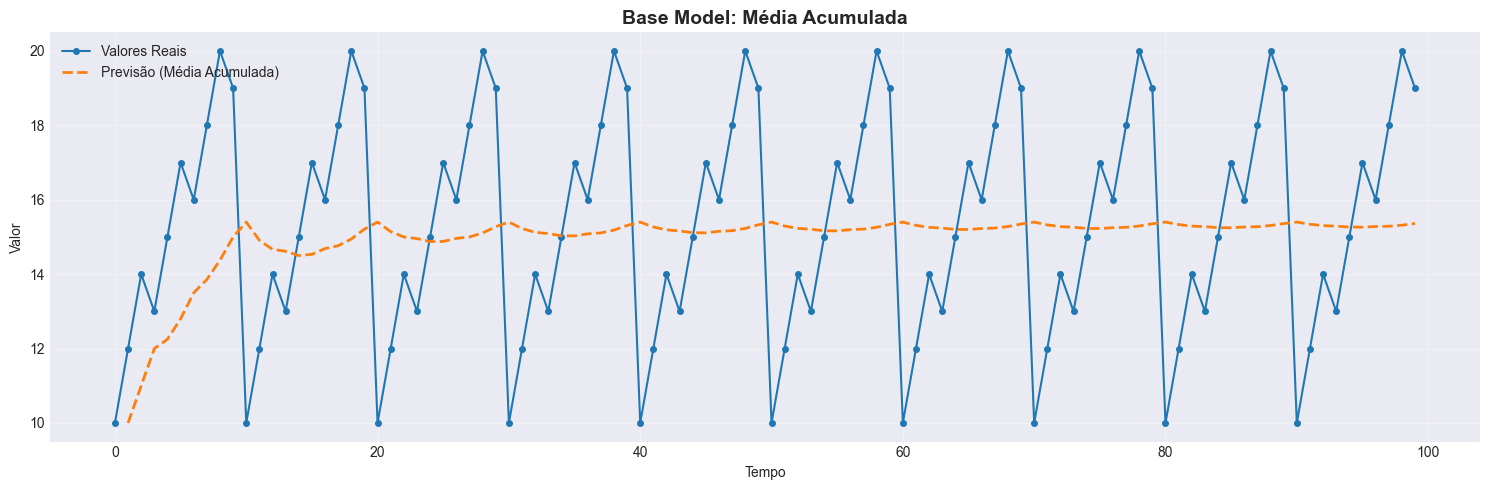

In [5]:
def media_acumulada(serie):
    """
    Base Model: Média Acumulada
    Prevê cada valor como a média de todos os valores anteriores.
    """
    n = len(serie)
    previsoes = np.full(n, np.nan)
    
    for t in range(1, n):
        previsoes[t] = np.mean(serie[:t])
    
    return previsoes

# Aplicar o modelo
prev_media_acum = media_acumulada(serie)

# Calcular e exibir métricas
metricas_media_acum = exibir_resultados('Média Acumulada', serie, prev_media_acum)

# Visualização
plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4)
plt.plot(prev_media_acum, label='Previsão (Média Acumulada)', linestyle='--', linewidth=2)
plt.title('Base Model: Média Acumulada', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Média Móvel Simples (SMA)

**Descrição**: Prevê o próximo valor usando a média dos últimos $k$ pontos observados.

**Fórmula**: $\hat{y}_{t+1} = \frac{1}{k} \sum_{i=t-k+1}^{t} y_i$

**Parâmetro**: `janela` (k) - número de observações recentes a considerar.

**Quando usar**: Suavizar ruídos, capturar tendências de curto prazo.


  Média Móvel Simples (janela=3)
  MAE     :     2.6082
  MSE     :    12.2577
  RMSE    :     3.5011
  MAPE    :    19.7876


  Média Móvel Simples (janela=5)
  MAE     :     3.2653
  MSE     :    14.2825
  RMSE    :     3.7792
  MAPE    :    23.5172


  Média Móvel Simples (janela=7)
  MAE     :     3.2258
  MSE     :    13.6787
  RMSE    :     3.6985
  MAPE    :    22.7142



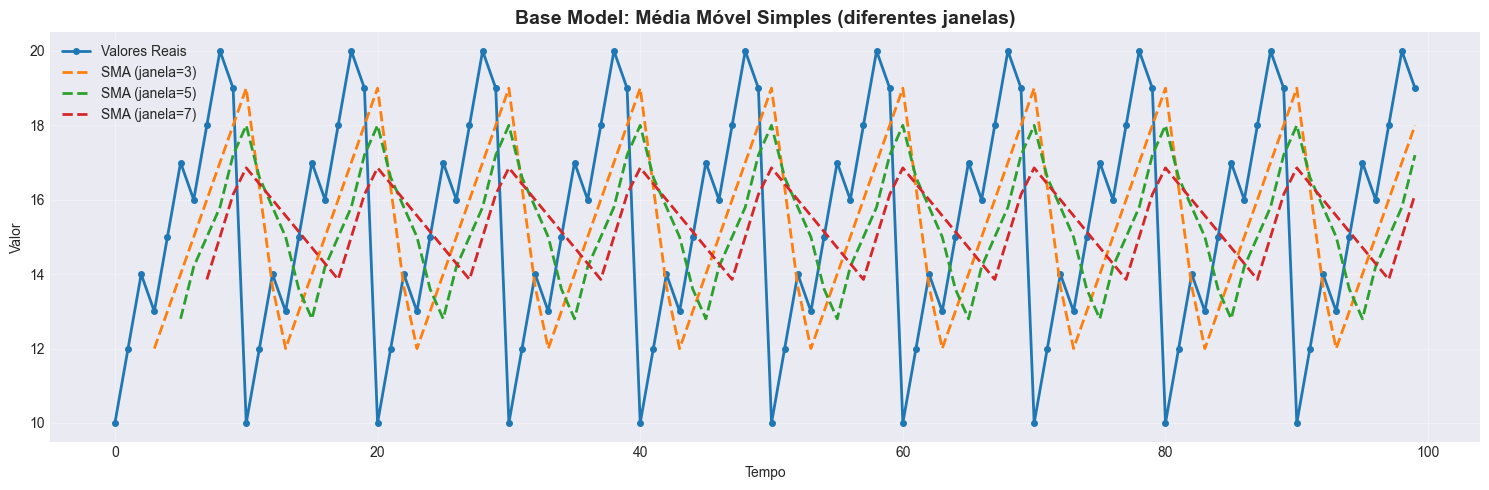

In [6]:
def media_movel_simples(serie, janela=5):
    """
    Base Model: Média Móvel Simples (SMA)
    Prevê o próximo valor como a média dos últimos k valores.
    
    Parâmetros:
    -----------
    serie : array-like
        Série temporal
    janela : int
        Tamanho da janela móvel (padrão: 5)
    """
    n = len(serie)
    previsoes = np.full(n, np.nan)
    
    for t in range(janela, n):
        previsoes[t] = np.mean(serie[t-janela:t])
    
    return previsoes

# Testar com diferentes janelas
janelas = [3, 5, 7]
resultados_sma = {}

plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4, linewidth=2)

for janela in janelas:
    prev = media_movel_simples(serie, janela=janela)
    resultados_sma[f'SMA_{janela}'] = prev
    metricas = exibir_resultados(f'Média Móvel Simples (janela={janela})', serie, prev)
    plt.plot(prev, label=f'SMA (janela={janela})', linestyle='--', linewidth=2)

plt.title('Base Model: Média Móvel Simples (diferentes janelas)', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Média Móvel Exponencial (EMA)

**Descrição**: Média que atribui pesos maiores aos valores mais recentes, decaindo exponencialmente para os mais antigos.

**Fórmula**: $\hat{y}_{t+1} = \alpha \cdot y_t + (1 - \alpha) \cdot \hat{y}_t$

**Parâmetro**: `alpha` (α) - peso do valor mais recente (0 < α ≤ 1).
- α próximo de 1: reage rápido a mudanças
- α próximo de 0: mais suave, menos sensível

**Quando usar**: Quando valores recentes são mais importantes, dados com tendências.


  Média Móvel Exponencial (alpha=0.3)
  MAE     :     2.6153
  MSE     :    10.7086
  RMSE    :     3.2724
  MAPE    :    19.0381


  Média Móvel Exponencial (alpha=0.5)
  MAE     :     2.2988
  MSE     :    10.3291
  RMSE    :     3.2139
  MAPE    :    17.3717


  Média Móvel Exponencial (alpha=0.8)
  MAE     :     2.1006
  MSE     :     9.9678
  RMSE    :     3.1572
  MAPE    :    16.0861



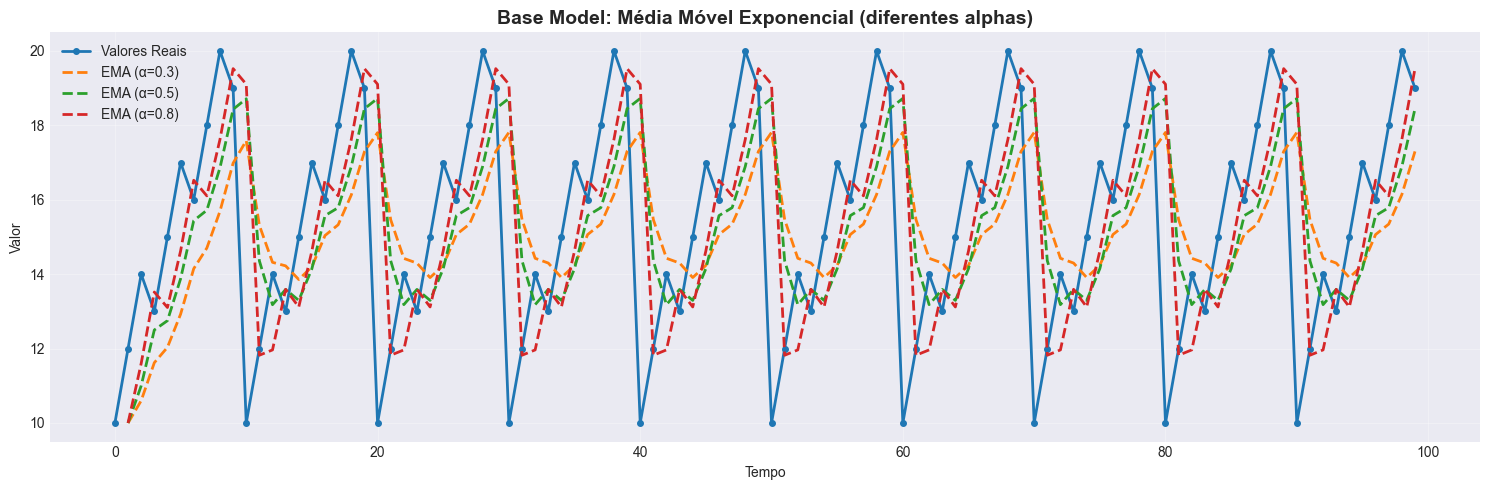

In [7]:
def media_movel_exponencial(serie, alpha=0.8):
    """
    Base Model: Média Móvel Exponencial (EMA)
    Prevê com pesos exponencialmente decrescentes para valores passados.
    
    Parâmetros:
    -----------
    serie : array-like
        Série temporal
    alpha : float
        Peso do valor mais recente, entre 0 e 1 (padrão: 0.8)
    """
    n = len(serie)
    previsoes = np.full(n, np.nan)
    
    # Primeiro valor: usa o valor anterior
    previsoes[1] = serie[0]
    
    # Cálculo recursivo do EMA
    for t in range(2, n):
        previsoes[t] = alpha * serie[t-1] + (1 - alpha) * previsoes[t-1]
    
    return previsoes

# Testar com diferentes valores de alpha
alphas = [0.3, 0.5, 0.8]
resultados_ema = {}

plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4, linewidth=2)

for alpha in alphas:
    prev = media_movel_exponencial(serie, alpha=alpha)
    resultados_ema[f'EMA_{alpha}'] = prev
    metricas = exibir_resultados(f'Média Móvel Exponencial (alpha={alpha})', serie, prev)
    plt.plot(prev, label=f'EMA (α={alpha})', linestyle='--', linewidth=2)

plt.title('Base Model: Média Móvel Exponencial (diferentes alphas)', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Taxa de Variação

**Descrição**: Prevê cada novo valor com base na variação percentual entre o valor atual e o valor de $k$ períodos atrás.

**Fórmula**: 
$$taxa = \frac{y_t - y_{t-k}}{y_{t-k}}$$
$$\hat{y}_{t+1} = y_t \cdot (1 + taxa)$$

**Parâmetro**: `janela` (k) - distância temporal para calcular a variação.

**Quando usar**: Séries com crescimento/decrescimento percentual constante.


  Taxa de Variação (janela=2)
  MAE     :      4.503
  MSE     :    30.3146
  RMSE    :     5.5059
  MAPE    :    33.7147


  Taxa de Variação (janela=3)
  MAE     :     4.3496
  MSE     :    29.3418
  RMSE    :     5.4168
  MAPE    :    33.0117


  Taxa de Variação (janela=5)
  MAE     :     7.0477
  MSE     :    66.6753
  RMSE    :     8.1655
  MAPE    :    49.2179



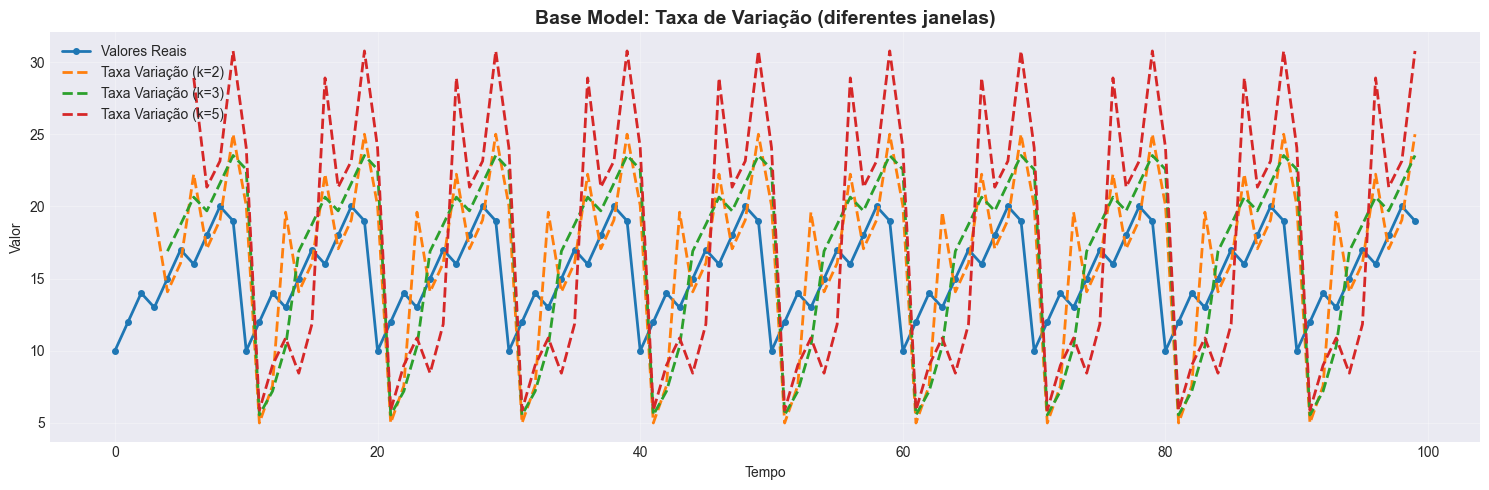

In [8]:
def taxa_variacao(serie, janela=2):
    """
    Base Model: Taxa de Variação
    Prevê com base na variação percentual dos últimos k períodos.
    
    Parâmetros:
    -----------
    serie : array-like
        Série temporal
    janela : int
        Número de períodos para calcular a taxa (padrão: 2)
    """
    n = len(serie)
    previsoes = np.full(n, np.nan)
    
    for t in range(janela + 1, n):
        y_atual = serie[t-1]
        y_anterior = serie[t-1-janela]
        
        # Evitar divisão por zero
        if y_anterior != 0:
            taxa = (y_atual - y_anterior) / y_anterior
            previsoes[t] = y_atual * (1 + taxa)
    
    return previsoes

# Testar com diferentes janelas
janelas = [2, 3, 5]
resultados_taxa = {}

plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4, linewidth=2)

for janela in janelas:
    prev = taxa_variacao(serie, janela=janela)
    resultados_taxa[f'Taxa_{janela}'] = prev
    metricas = exibir_resultados(f'Taxa de Variação (janela={janela})', serie, prev)
    plt.plot(prev, label=f'Taxa Variação (k={janela})', linestyle='--', linewidth=2)

plt.title('Base Model: Taxa de Variação (diferentes janelas)', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Seasonal Naive

**Descrição**: Prevê o próximo valor como o valor observado $s$ períodos atrás. Assume repetição sazonal.

**Fórmula**: $\hat{y}_{t+1} = y_{t+1-s}$

**Parâmetro**: `sazonalidade` (s) - período sazonal (ex: 7 para dados diários com padrão semanal).

**Quando usar**: Séries com sazonalidade clara e repetitiva.


  Seasonal Naive (sazonalidade=5)
  MAE     :        5.2
  MSE     :       29.2
  RMSE    :     5.4037
  MAPE    :    35.3292


  Seasonal Naive (sazonalidade=7)
  MAE     :     4.2903
  MSE     :    22.5484
  RMSE    :     4.7485
  MAPE    :     26.997


  Seasonal Naive (sazonalidade=10)
  MAE     :        0.0
  MSE     :        0.0
  RMSE    :        0.0
  MAPE    :        0.0



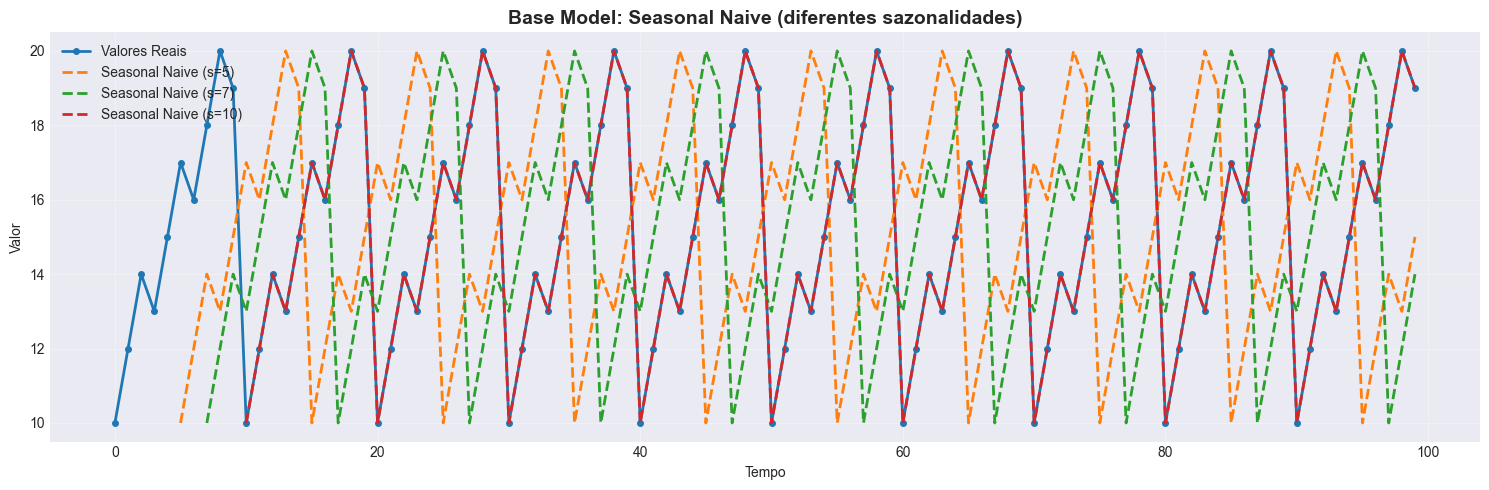

In [9]:
def seasonal_naive(serie, sazonalidade=7):
    """
    Base Model: Seasonal Naive
    Prevê como o valor observado s períodos atrás (repetição sazonal).
    
    Parâmetros:
    -----------
    serie : array-like
        Série temporal
    sazonalidade : int
        Período sazonal (padrão: 7)
    """
    n = len(serie)
    previsoes = np.full(n, np.nan)
    
    for t in range(sazonalidade, n):
        previsoes[t] = serie[t - sazonalidade]
    
    return previsoes

# Testar com diferentes sazonalidades
sazonalidades = [5, 7, 10]
resultados_snaive = {}

plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4, linewidth=2)

for s in sazonalidades:
    prev = seasonal_naive(serie, sazonalidade=s)
    resultados_snaive[f'SNaive_{s}'] = prev
    metricas = exibir_resultados(f'Seasonal Naive (sazonalidade={s})', serie, prev)
    plt.plot(prev, label=f'Seasonal Naive (s={s})', linestyle='--', linewidth=2)

plt.title('Base Model: Seasonal Naive (diferentes sazonalidades)', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Delta (Drift)

**Descrição**: Projeta o próximo valor com base na tendência média dos últimos $k$ períodos.

**Fórmula**: 
$$delta = \frac{y_t - y_{t-k}}{k}$$
$$\hat{y}_{t+1} = y_t + delta$$

**Parâmetro**: `janela` (k) - número de períodos para calcular a tendência.

**Quando usar**: Séries com tendência linear, crescimento/decrescimento constante.


  Delta (janela=2)
  MAE     :     3.5876
  MSE     :    19.4381
  RMSE    :     4.4089
  MAPE    :    27.3846


  Delta (janela=3)
  MAE     :     2.7083
  MSE     :      14.75
  RMSE    :     3.8406
  MAPE    :    21.4319


  Delta (janela=5)
  MAE     :     2.9106
  MSE     :     14.446
  RMSE    :     3.8008
  MAPE    :    22.1922



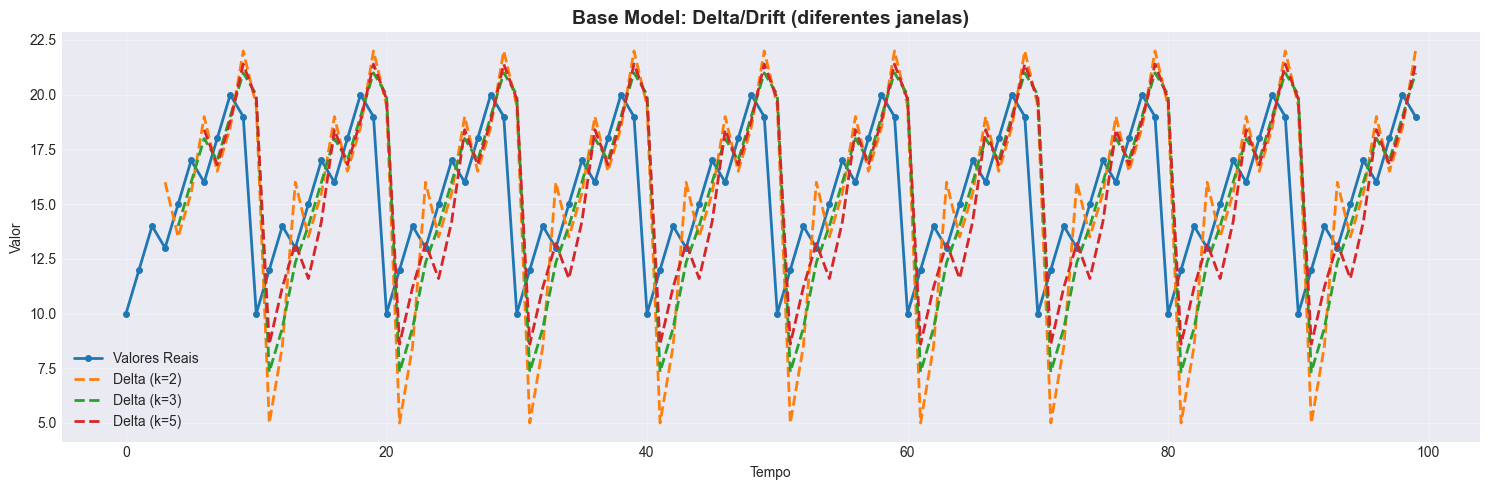

In [10]:
def delta_drift(serie, janela=2):
    """
    Base Model: Delta (Drift)
    Prevê com base na tendência média dos últimos k períodos.
    
    Parâmetros:
    -----------
    serie : array-like
        Série temporal
    janela : int
        Número de períodos para calcular o delta (padrão: 2)
    """
    n = len(serie)
    previsoes = np.full(n, np.nan)
    
    for t in range(janela + 1, n):
        y_atual = serie[t-1]
        y_anterior = serie[t-1-janela]
        delta = (y_atual - y_anterior) / janela
        previsoes[t] = y_atual + delta
    
    return previsoes

# Testar com diferentes janelas
janelas = [2, 3, 5]
resultados_delta = {}

plt.figure(figsize=(15, 5))
plt.plot(serie, label='Valores Reais', marker='o', markersize=4, linewidth=2)

for janela in janelas:
    prev = delta_drift(serie, janela=janela)
    resultados_delta[f'Delta_{janela}'] = prev
    metricas = exibir_resultados(f'Delta (janela={janela})', serie, prev)
    plt.plot(prev, label=f'Delta (k={janela})', linestyle='--', linewidth=2)

plt.title('Base Model: Delta/Drift (diferentes janelas)', fontsize=14, fontweight='bold')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparação de Todos os Modelos

Resumo das métricas de todos os base models testados.


  COMPARAÇÃO DE TODOS OS BASE MODELS


,Modelo,MAE,MSE,RMSE,MAPE
3,EMA (alpha=0.5),2.2988,10.3291,3.2139,17.3717
0,Média Histórica,2.5717,9.0388,3.0065,17.9409
1,Média Acumulada,2.6809,9.7347,3.1201,18.4108
2,SMA (janela=5),3.2653,14.2825,3.7792,23.5172
6,Delta (k=2),3.5876,19.4381,4.4089,27.3846
5,Seasonal Naive (s=7),4.2903,22.5484,4.7485,26.9970
4,Taxa Variação (k=2),4.5030,30.3146,5.5059,33.7147


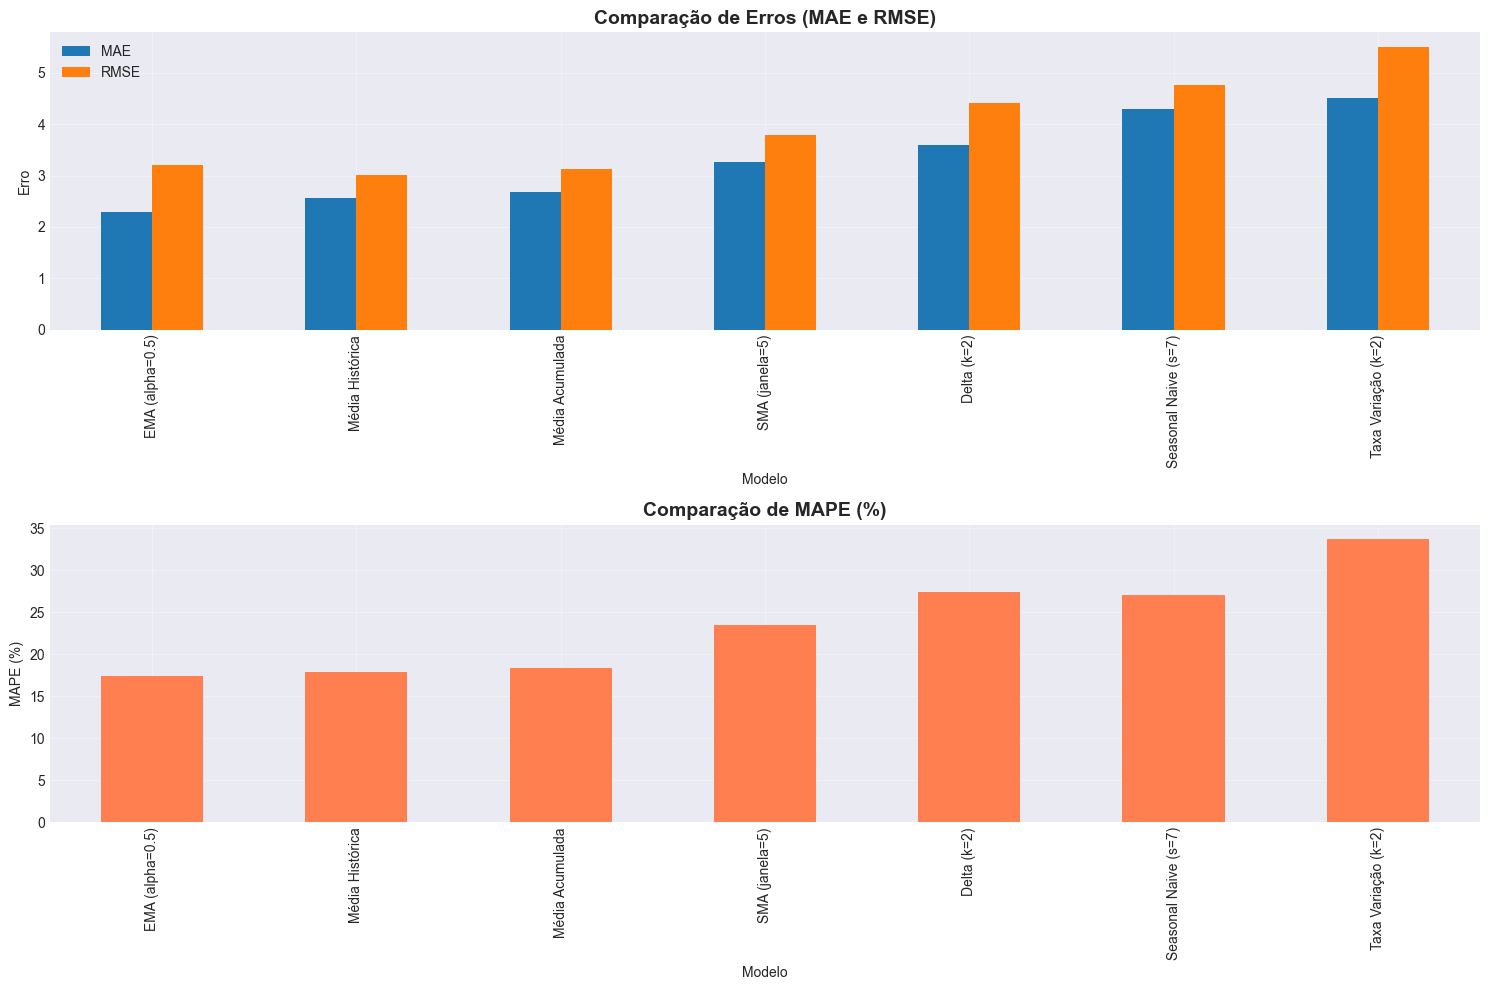


🏆 MELHOR MODELO: EMA (alpha=0.5)
   MAE: 2.2988
   MAPE: 17.3717%



In [11]:
# Compilar todos os resultados
todos_modelos = {
    'Média Histórica': prev_media_hist,
    'Média Acumulada': prev_media_acum,
    'SMA (janela=5)': resultados_sma.get('SMA_5'),
    'EMA (alpha=0.5)': resultados_ema.get('EMA_0.5'),
    'Taxa Variação (k=2)': resultados_taxa.get('Taxa_2'),
    'Seasonal Naive (s=7)': resultados_snaive.get('SNaive_7'),
    'Delta (k=2)': resultados_delta.get('Delta_2')
}

# Calcular métricas para comparação
comparacao = []
for nome, previsoes in todos_modelos.items():
    if previsoes is not None:
        metricas = calcular_metricas(serie, previsoes)
        metricas['Modelo'] = nome
        comparacao.append(metricas)

# Criar DataFrame de comparação
df_comparacao = pd.DataFrame(comparacao)
df_comparacao = df_comparacao[['Modelo', 'MAE', 'MSE', 'RMSE', 'MAPE']]
df_comparacao = df_comparacao.sort_values('MAE')

print("\n" + "="*80)
print("  COMPARAÇÃO DE TODOS OS BASE MODELS")
print("="*80)
display(df_comparacao)
print("="*80)

# Visualização comparativa
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Métricas de erro
df_comparacao.set_index('Modelo')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparação de Erros (MAE e RMSE)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Erro')
axes[0].legend(['MAE', 'RMSE'])
axes[0].grid(True, alpha=0.3)

# Gráfico 2: MAPE
df_comparacao.set_index('Modelo')['MAPE'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Comparação de MAPE (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar o melhor modelo
melhor_modelo = df_comparacao.iloc[0]
print(f"\n🏆 MELHOR MODELO: {melhor_modelo['Modelo']}")
print(f"   MAE: {melhor_modelo['MAE']}")
print(f"   MAPE: {melhor_modelo['MAPE']}%\n")

## Exportar Resultados

Salva as previsões e métricas em arquivo CSV.

In [12]:
# Criar DataFrame com todas as previsões
df_resultados = pd.DataFrame({
    'valor_real': serie,
    'media_historica': prev_media_hist,
    'media_acumulada': prev_media_acum
})

# Adicionar outros modelos
for nome, prev in {**resultados_sma, **resultados_ema, **resultados_taxa, **resultados_snaive, **resultados_delta}.items():
    df_resultados[nome] = prev

# Salvar em CSV
output_path = '/Users/mayumi.castiglioni/Downloads/base_models_resultados.csv'
df_resultados.to_csv(output_path, index=False)
print(f"✅ Resultados salvos em: {output_path}")

# Salvar comparação de métricas
metricas_path = '/Users/mayumi.castiglioni/Downloads/base_models_metricas.csv'
df_comparacao.to_csv(metricas_path, index=False)
print(f"✅ Métricas salvas em: {metricas_path}")

OSError: Cannot save file into a non-existent directory: '\Users\mayumi.castiglioni\Downloads'